# Проверка данных

Для анализа использовались данные о количестве онлайн пользователей в одной из игр.

In [123]:
import sys
import warnings
from tarfile import data_filter

warnings.filterwarnings('ignore')
from tqdm import tqdm

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [124]:
def plotly_df(df, title = ''):
    for col in df.columns:
        plt.plot(df.index,df[col], label=col)

    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45, ha='right')
    plt.show()

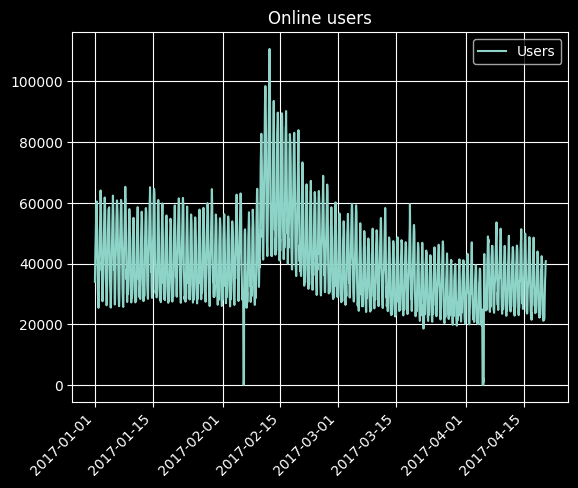

In [125]:
dataset = pd.read_csv('hour_online.csv', index_col=['Time'], parse_dates=['Time'])
plotly_df(dataset, title = "Online users")

In [126]:
def plotMovingAverage(series, n):
    """
    series - dataframe with timeseries
    n - rolling window size
    """
    rolling_mean = series.rolling(window=n).mean()
    rolling_std =  series.rolling(window=n).std()
    upper_bond = rolling_mean+1.96*rolling_std
    lower_bond = rolling_mean-1.96*rolling_std

    plt.figure(figsize=(15,5))
    plt.title("Moving average\n window size = {}".format(n))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
    plt.plot(lower_bond, "r--")
    plt.plot(dataset[n:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)

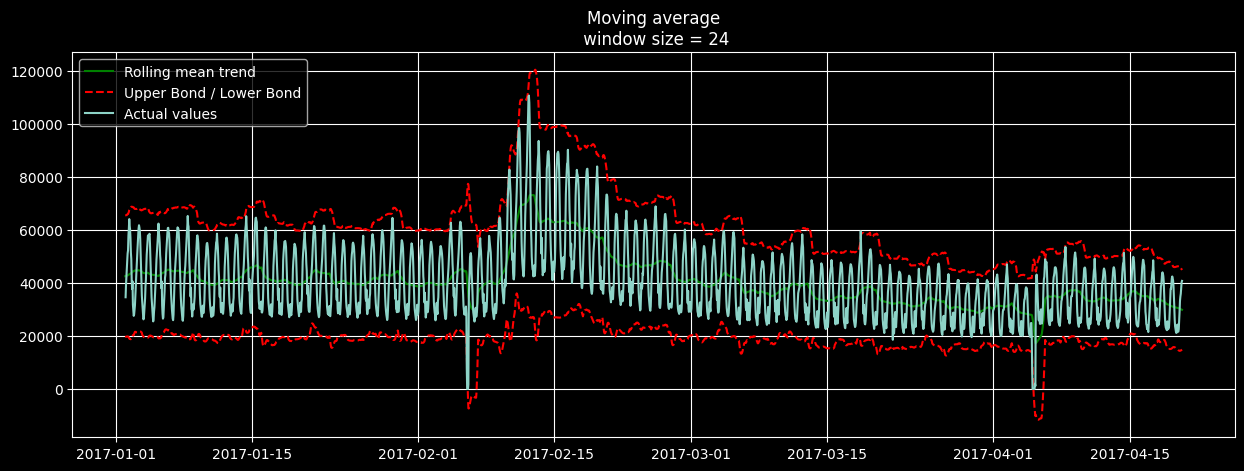

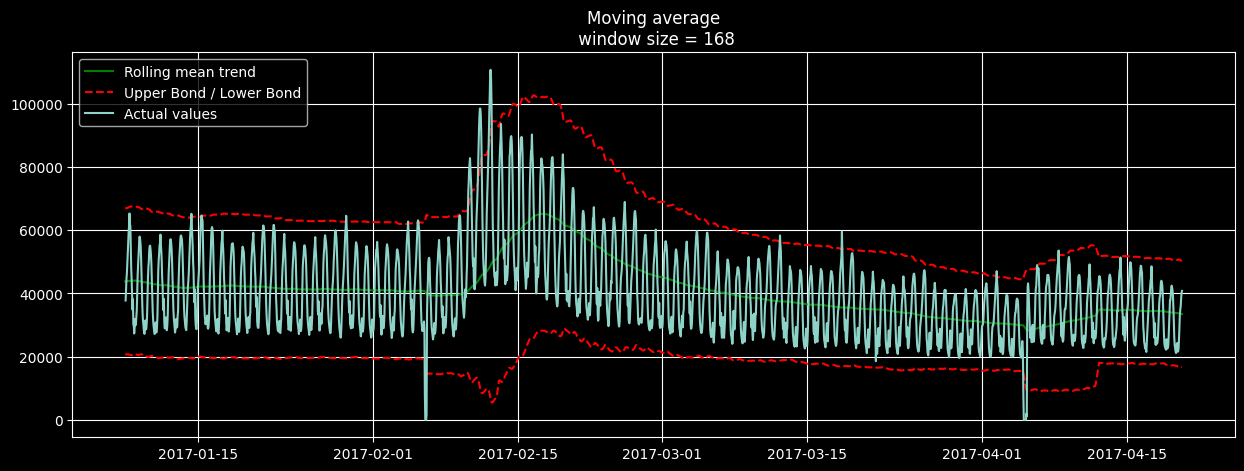

In [127]:
plotMovingAverage(dataset, 24)
plotMovingAverage(dataset, 24*7)

Из графиков видно, что есть прирост игроков каждую неделю по выходным. А так же заметна общая тенденция, рост в феврале и дальше спад.

Критерий Дики-Фуллера: p=0.190189


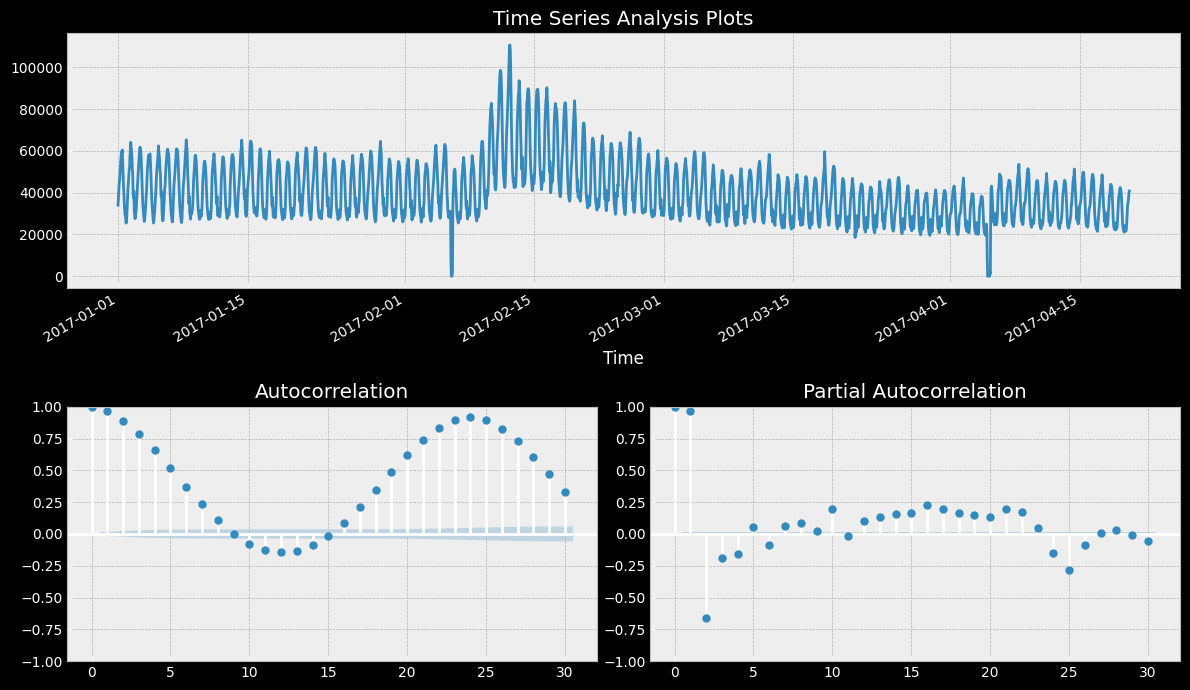

In [128]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        ts_ax.set_title('Time Series Analysis Plots')
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5)

        print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(y)[1])

        plt.tight_layout()
    return

tsplot(dataset.Users, lags=30)

 Исходный ряд стационарным не является, критерий Дики-Фуллера не отверг нулевую гипотезу о наличии единичного корня.

Критерий Дики-Фуллера: p=0.079760
Оптимальный параметр преобразования Бокса-Кокса: 0.587270


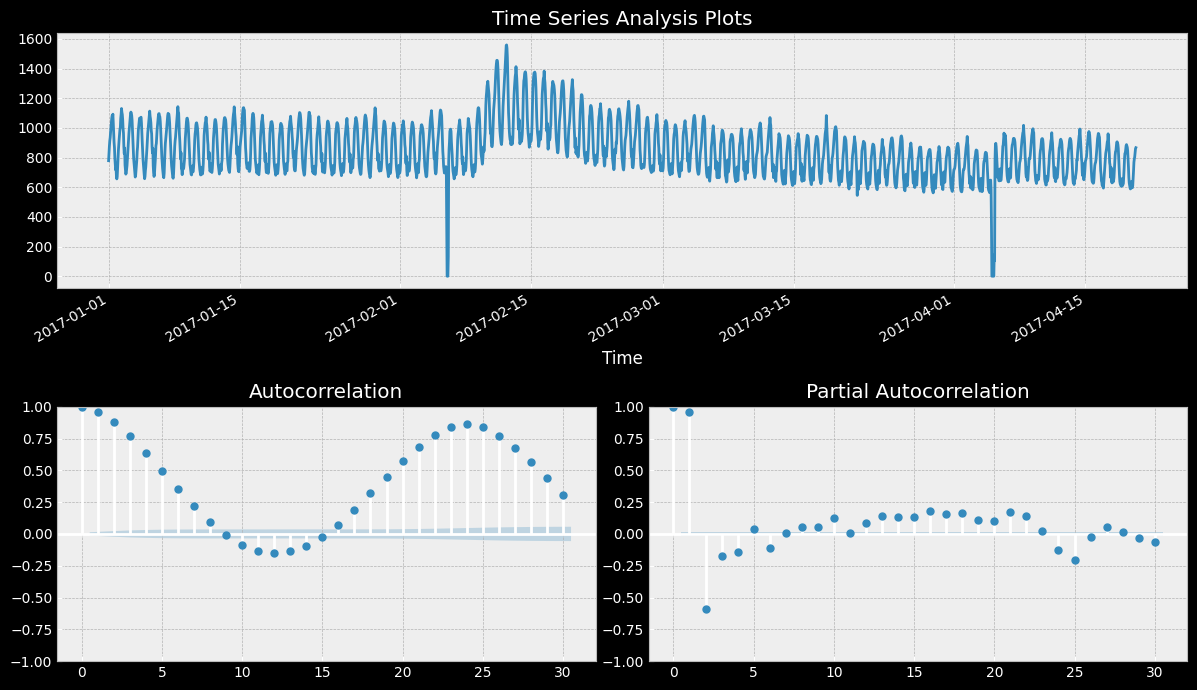

In [129]:
def invboxcox(y,lmbda):
    # обрабтное преобразование Бокса-Кокса
    if lmbda == 0:
        return(np.exp(y))
    else:
        return(np.exp(np.log(lmbda*y+1)/lmbda))

data = dataset.copy()
data['Users_box'], lmbda = scs.boxcox(data.Users+1) # прибавляем единицу, так как в исходном ряде есть нули
tsplot(data.Users_box, lags=30)
print("Оптимальный параметр преобразования Бокса-Кокса: %f" % lmbda)

Критерий Дики-Фуллера по-прежнему не отвергает гипотезу о нестационарности ряда. А автокорреляционная функция явно намекает на сезонность в получившемся ряде.

Критерий Дики-Фуллера: p=0.002571


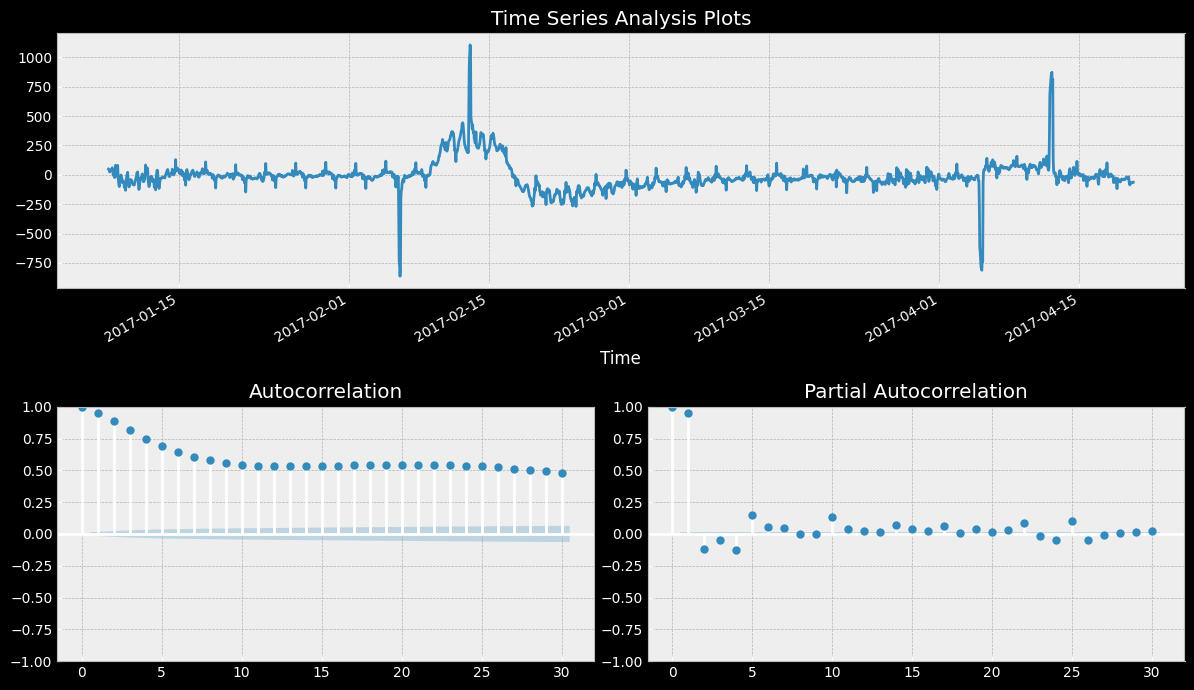

In [130]:
data['Users_box_season'] = data.Users_box - data.Users_box.shift(24*7)
tsplot(data.Users_box_season[24*7:], lags=30)

Критерий Дики-Фуллера теперь отвергает нулевую гипотезу о нестационарности, но автокорреляционная функция всё ещё выглядит нехорошо из-за большого числа значимых лагов. Так как на графике частной автокорреляционной функции значим лишь один лаг, стоит взять еще первые разности, чтобы привести наконец ряд к стационарному виду.

Критерий Дики-Фуллера: p=0.000000


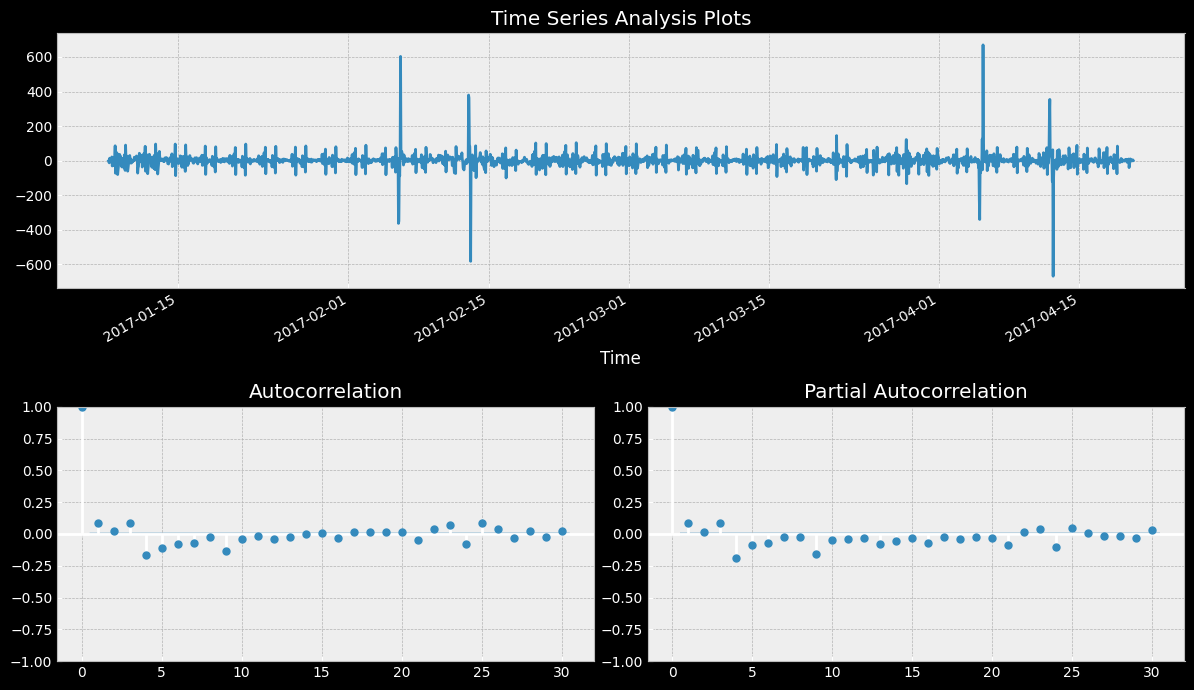

In [131]:
data['Users_box_season_diff'] = data.Users_box_season - data.Users_box_season.shift(1)
tsplot(data.Users_box_season_diff[24*7+1:], lags=30)

In [132]:
data_train = data.iloc[:-100].copy()
data_test = data.iloc[-100:].copy()

In [133]:
data_train['Users_box'], lmbda = scs.boxcox(data_train['Users'] + 1)
data_test['Users_box'] = scs.boxcox(data_test['Users'] + 1, lmbda=lmbda)


# ARIMA

In [134]:
ps = range(0, 5)
d=1
qs = range(0, 5)

from itertools import product

parameters = product(ps, qs)
parameters_list = list(parameters)
len(parameters_list)

25

In [135]:
results = []
best_aic = float("inf")

for param in tqdm(parameters_list):
    #try except нужен, потому что на некоторых наборах параметров модель не обучается
    try:
        model= ARIMA(data_train.Users_box, order=(param[0], d, param[1])).fit()
    #выводим параметры, на которых модель не обучается и переходим к следующему набору
    except ValueError:
        print('wrong parameters:', param)
        continue
    aic = model.aic
    #сохраняем лучшую модель, aic, параметры
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])

warnings.filterwarnings('default')

result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'aic']
print(result_table.sort_values(by = 'aic', ascending=True).head())


100%|██████████| 25/25 [00:21<00:00,  1.17it/s]

   parameters           aic
18     (3, 3)  25634.843509
22     (4, 2)  25639.933732
23     (4, 3)  25655.861624
24     (4, 4)  25735.160204
17     (3, 2)  26235.637514


In [136]:
best_model = ARIMA(data_train.Users_box, order=(3, d,3)).fit()
print(best_model.summary())

D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Users_box   No. Observations:                 2525
Model:                 ARIMA(3, 1, 3)   Log Likelihood              -12810.422
Date:                Wed, 01 Apr 2026   AIC                          25634.844
Time:                        20:09:29   BIC                          25675.679
Sample:                             0   HQIC                         25649.661
                               - 2525                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5780      0.051     30.664      0.000       1.477       1.679
ar.L2         -0.3345      0.098     -3.422      0.001      -0.526      -0.143
ar.L3         -0.3335      0.050     -6.663      0.0

Критерий Дики-Фуллера: p=0.000000


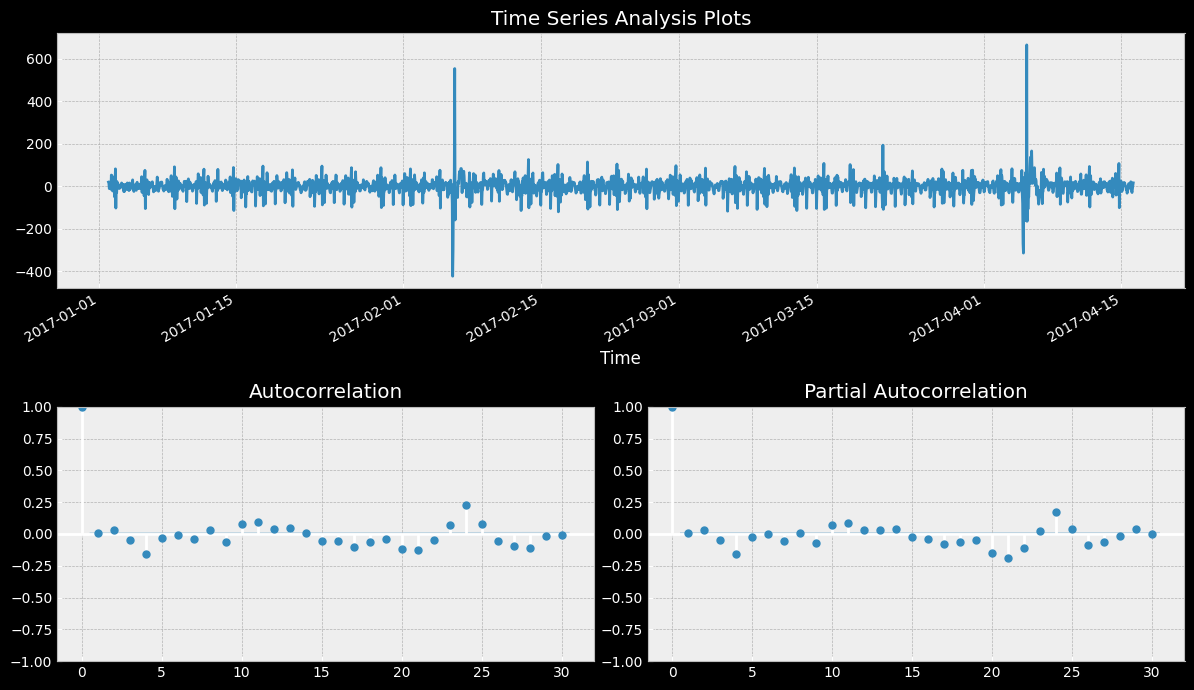

In [137]:
tsplot(best_model.resid[24:], lags=30)

In [138]:
train_fitted = pd.Series(
    invboxcox(best_model.fittedvalues, lmbda),
    index=data_train.index
)

D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [139]:
forecast_box = best_model.get_forecast(steps=len(data_test)).predicted_mean

D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [140]:
if lmbda != 0:
    eps = 1e-9
    if lmbda > 0:
        forecast_box = forecast_box.clip(lower=(-1.0 / lmbda) + eps)
    else:
        forecast_box = forecast_box.clip(upper=(-1.0 / lmbda) - eps)

In [141]:
forecast = pd.Series(
    invboxcox(forecast_box, lmbda),
    index=data_test.index
)

In [142]:
print("NaN in forecast:", forecast.isna().sum())

NaN in forecast: 100


In [143]:
mae_test = mean_absolute_error(data_test['Users'], forecast)
print(f"Test MAE: {mae_test:.2f}")

ValueError: Input contains NaN.

In [ ]:
pred_all = pd.concat([train_fitted, forecast])

plt.figure(figsize=(15, 7))
plt.plot(data['Users'], label='actual', color='black')
plt.plot(pred_all, label='model', color='red')
plt.axvline(data_test.index[0], color='gray', linestyle='--', label='train/test split')
plt.title(f"ARIMA model\nTest MAE = {mae_test:.2f} users")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(forecast_box.head())
print(forecast_box.min(), forecast_box.max())